В цьому домашньому завданні ми побудуємо рішення задачі логістичної регресії і створимо ваш перший submission на змагання на Kaggle. Усі кроки були розглянуті в лекції та містяться в ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb`, але тепер ми їх адаптуємо до іншої задачі - все як в реальному житті, коли ви знайшли код у відкритих джерелах і адаптуєте на проєкті 😉

**Погнали! 🚀🚀🚀**

-----------



0. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle) Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").

1. Зчитайте дані `train.csv` в pandas dataframe та розбийте їх на train і validation піднабори.

  * Є такий параметр в методі train_test_split як stratified. Можливо він буде Вам корисним при розбитті даних в цій задачі. Пропоную Вам почитати про нього в документації і спробувати скористатись.

In [1]:
# Імпортування потрібних бібліотек та методів
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import f1_score

In [2]:
# Зчитування даних train.csv в pandas dataframe та виведення перших 5 записів
bank_df = pd.read_csv('train.csv')
bank_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15779985.0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,1,15650086.0,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,2,15733602.0,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,3,15645794.0,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,4,15633840.0,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0


In [3]:
# Виведення загальної інформації про набір даних bank_df
bank_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               15000 non-null  int64  
 1   CustomerId       15000 non-null  float64
 2   Surname          15000 non-null  object 
 3   CreditScore      15000 non-null  float64
 4   Geography        15000 non-null  object 
 5   Gender           15000 non-null  object 
 6   Age              15000 non-null  float64
 7   Tenure           15000 non-null  float64
 8   Balance          15000 non-null  float64
 9   NumOfProducts    15000 non-null  float64
 10  HasCrCard        15000 non-null  float64
 11  IsActiveMember   15000 non-null  float64
 12  EstimatedSalary  15000 non-null  float64
 13  Exited           15000 non-null  float64
dtypes: float64(10), int64(1), object(3)
memory usage: 1.6+ MB


In [4]:
# Розбиття даних на train і validation піднабори з параметром stratify для цільової колонки
train_df, val_df = train_test_split(bank_df, test_size = 0.25, random_state = 42, stratify = bank_df['Exited'])
train_df

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
8263,8263,15679299.0,Toscani,696.0,France,Male,32.0,5.0,130627.66,1.0,1.0,1.0,86786.41,0.0
14199,14199,15804862.0,Kuo,632.0,Germany,Female,32.0,4.0,119825.75,1.0,1.0,0.0,177737.04,1.0
1856,1856,15613140.0,Ejimofor,679.0,France,Female,22.0,4.0,0.00,2.0,1.0,1.0,162599.54,0.0
3013,3013,15651955.0,Onochie,705.0,France,Male,48.0,3.0,0.00,2.0,1.0,0.0,119814.25,0.0
8266,8266,15768471.0,Chukwuemeka,696.0,France,Female,35.0,7.0,0.00,2.0,1.0,0.0,100423.88,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9493,9493,15711299.0,Onyekachi,633.0,France,Female,33.0,4.0,0.00,2.0,0.0,0.0,123537.05,0.0
7687,7687,15641411.0,McGregor,645.0,Spain,Male,33.0,3.0,87541.06,1.0,1.0,0.0,135077.01,1.0
8143,8143,15585192.0,Hsia,621.0,France,Male,29.0,8.0,0.00,2.0,1.0,1.0,133535.29,0.0
11512,11512,15694450.0,Onuora,590.0,Spain,Male,42.0,7.0,0.00,2.0,0.0,0.0,72643.95,0.0


In [5]:
val_df

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
1855,1855,15751177.0,Bitter,543.0,France,Male,29.0,9.0,119688.81,1.0,0.0,0.0,55815.62,0.0
1273,1273,15685536.0,Ting,598.0,Germany,Male,41.0,3.0,123863.64,1.0,1.0,0.0,176868.89,0.0
5414,5414,15710456.0,Maclean,621.0,France,Male,31.0,7.0,0.00,1.0,1.0,1.0,150242.44,0.0
10923,10923,15610355.0,Chiang,597.0,France,Male,56.0,3.0,0.00,4.0,1.0,0.0,102936.71,1.0
5835,5835,15778947.0,Oluchi,749.0,Spain,Female,42.0,5.0,0.00,1.0,1.0,1.0,181794.86,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1036,1036,15642815.0,Chibugo,850.0,France,Female,34.0,4.0,0.00,2.0,1.0,0.0,180345.44,0.0
9017,9017,15608968.0,Ijendu,714.0,France,Female,37.0,6.0,0.00,2.0,1.0,0.0,153662.88,0.0
9963,9963,15753895.0,Chiganu,582.0,France,Male,28.0,4.0,98668.18,1.0,1.0,0.0,57589.29,0.0
13573,13573,15737354.0,Kumm,792.0,France,Female,35.0,5.0,0.00,1.0,1.0,0.0,179655.87,0.0


2. Визначіть назви колонок, які сформують вхідні незалежні дані, в змінній `input_cols` та назву колонки , яка є цільовою, в змінній `target_col`. Використовуючи `input_cols` та `target_col` створіть набори даних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` - де `inputs` - вхідні дані (датафрейм), `targets` - дані цільової колонки відповідного піднабору.

In [6]:
# Створення списку вхідних стовпців та визначення цільового стовпця
input_cols = list(train_df.columns)[2:-1]
target_col = 'Exited'

In [7]:
# Виведення списку вхідних стовпців
print(input_cols)

['Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']


In [8]:
# Створення наборів даних train_inputs, train_targets, де inputs - вхідні дані, targets - дані цільової колонки відповідного піднабору
train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_col].copy()

In [9]:
# Створення наборів даних val_inputs, val_targets, де inputs - вхідні дані, targets - дані цільової колонки відповідного піднабору
val_inputs = val_df[input_cols].copy()
val_targets = val_df[target_col].copy()

3. Визначіть з допомогою `pandas.DataFrame.select_dtypes` назви колонок, які є числовими і категоріальними. Запишіть результати в `numeric_cols` та `categorical_cols` відповідно.

In [10]:
# Виведення числових колонок
numeric_cols = bank_df.select_dtypes(include = "number").columns
numeric_cols

Index(['id', 'CustomerId', 'CreditScore', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='object')

In [11]:
# Виведення категоріальних колонок
categorical_cols = bank_df.select_dtypes(include = "object").columns
categorical_cols

Index(['Surname', 'Geography', 'Gender'], dtype='object')

4. Зробіть підготовку даних в категоріальних і числових колонках для входу в модель, виходячи з освоєного на даний момент на курсі. Варіанти передобробки, з якими ми вже знайомі:
  - масштабування числових ознак,
  - заповнення пропущених значень, якщо вони є,
  - кодування категоріальних ознак, вилучення ознак, якщо ми вважаємо, що ці дані нерелевантні для моделі аби ми не бачимо способу, як їх так закодувати, аби подати на вхід моделі.

  Тут є багато варіантів, як Ви побудуєте передобробку, важливо аби:
  1) передобробка мала сенс (немає сенсу заповнювати дані константою, яку ми не зрозуміло звідки взяли);   
  2) має бути виконана принаймні одна дія передобробки;
  3) обробка має бути виконана коректно і для тренувальних, і для вал. даних;
  4) чим вищий у Вас врешті вийде ROС AUC скор, тим більше шансів перемогти у змаганні :)

  Опишіть рішення проведення кожного з кроків передобробки. Для чого ви його робите? По завершенню виведіть по 5 значень з `train_inputs`, `val_inputs`, використовуючи `display()`.

In [12]:
# Аналіз кожного категоріального стовпця (виведення кількості унікальних значень та розподілу значень)
for col in categorical_cols:
    print("-" * 40)
    print(f"Аналіз стовпця: {col}")
    print(f"Кількість унікальних значень: {bank_df[col].nunique()}")
    print("\nРозподіл значень (value_counts):")
    print(bank_df[col].value_counts())
    print("-" * 40 + "\n")

----------------------------------------
Аналіз стовпця: Surname
Кількість унікальних значень: 764

Розподіл значень (value_counts):
Surname
Ch'iu      252
Ch'ien     241
Ch'ang     225
Hsia       204
T'ien      187
          ... 
Trejo        1
Purdy        1
Otoole       1
Sarratt      1
Liardet      1
Name: count, Length: 764, dtype: int64
----------------------------------------

----------------------------------------
Аналіз стовпця: Geography
Кількість унікальних значень: 3

Розподіл значень (value_counts):
Geography
France     9032
Spain      3303
Germany    2665
Name: count, dtype: int64
----------------------------------------

----------------------------------------
Аналіз стовпця: Gender
Кількість унікальних значень: 2

Розподіл значень (value_counts):
Gender
Male      8529
Female    6471
Name: count, dtype: int64
----------------------------------------



In [13]:
# Кодування колонки Gender з бінарними значеннями

# Присвоєння кодів значенням колонки Gender (1 для категорії з більшою кількістю значень)
Gender_Codes = {'Female': 0, 'Male': 1}

# Створення колонки Gender_Code у train_inputs
train_inputs['Gender_Code'] = train_inputs.Gender.map(Gender_Codes)

# Створення колонки Gender_Code у val_inputs
val_inputs['Gender_Code'] = val_inputs.Gender.map(Gender_Codes)

In [14]:
# Кодування мультикатегоріальної колонки Geography з використанням sklearn.preprocessing.OneHotEncoder

# Ініціалізація енкодеру
enc = OneHotEncoder(sparse_output = False, # повернення масиву NumPy
                    handle_unknown = 'ignore')

# Навчання енкодеру на тренувальних даних
enc.fit(train_inputs[['Geography']])

# Отримання текстових назв для нових стовпців
encoded_cols = enc.categories_[0]

# Трансформування train_inputs та створення з нього нового датафрейму
train_inputs_encoded = pd.DataFrame(enc.transform(train_inputs[['Geography']]), columns = encoded_cols, index = train_inputs.index)
# Об'єднання з оригінальним train_inputs та видалення стовпця 'Geography'
train_inputs = pd.concat([train_inputs.drop(columns = ['Geography']), train_inputs_encoded], axis = 1)

# Трансформування val_inputs та створення з нього нового датафрейму
val_inputs_encoded = pd.DataFrame(enc.transform(val_inputs[['Geography']]), columns = encoded_cols, index = val_inputs.index)
# Об'єднання з оригінальним val_inputs та видалення стовпця 'Geography'
val_inputs = pd.concat([val_inputs.drop(columns = ['Geography']), val_inputs_encoded], axis = 1)

In [15]:
# Видалення нечислових колонок з train_inputs
train_inputs = train_inputs.drop(columns = train_inputs.select_dtypes(include = ['object']).columns)

# Видалення нечислових колонок з val_inputs
val_inputs = val_inputs.drop(columns = val_inputs.select_dtypes(include = ['object']).columns)

In [16]:
train_inputs

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Gender_Code,France,Germany,Spain
8263,696.0,32.0,5.0,130627.66,1.0,1.0,1.0,86786.41,1,1.0,0.0,0.0
14199,632.0,32.0,4.0,119825.75,1.0,1.0,0.0,177737.04,0,0.0,1.0,0.0
1856,679.0,22.0,4.0,0.00,2.0,1.0,1.0,162599.54,0,1.0,0.0,0.0
3013,705.0,48.0,3.0,0.00,2.0,1.0,0.0,119814.25,1,1.0,0.0,0.0
8266,696.0,35.0,7.0,0.00,2.0,1.0,0.0,100423.88,0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
9493,633.0,33.0,4.0,0.00,2.0,0.0,0.0,123537.05,0,1.0,0.0,0.0
7687,645.0,33.0,3.0,87541.06,1.0,1.0,0.0,135077.01,1,0.0,0.0,1.0
8143,621.0,29.0,8.0,0.00,2.0,1.0,1.0,133535.29,1,1.0,0.0,0.0
11512,590.0,42.0,7.0,0.00,2.0,0.0,0.0,72643.95,1,0.0,0.0,1.0


In [17]:
val_inputs

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Gender_Code,France,Germany,Spain
1855,543.0,29.0,9.0,119688.81,1.0,0.0,0.0,55815.62,1,1.0,0.0,0.0
1273,598.0,41.0,3.0,123863.64,1.0,1.0,0.0,176868.89,1,0.0,1.0,0.0
5414,621.0,31.0,7.0,0.00,1.0,1.0,1.0,150242.44,1,1.0,0.0,0.0
10923,597.0,56.0,3.0,0.00,4.0,1.0,0.0,102936.71,1,1.0,0.0,0.0
5835,749.0,42.0,5.0,0.00,1.0,1.0,1.0,181794.86,0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1036,850.0,34.0,4.0,0.00,2.0,1.0,0.0,180345.44,0,1.0,0.0,0.0
9017,714.0,37.0,6.0,0.00,2.0,1.0,0.0,153662.88,0,1.0,0.0,0.0
9963,582.0,28.0,4.0,98668.18,1.0,1.0,0.0,57589.29,1,1.0,0.0,0.0
13573,792.0,35.0,5.0,0.00,1.0,1.0,0.0,179655.87,0,1.0,0.0,0.0


In [18]:
# Масштабування незалежних числових змінних, використовуючи MinMaxScaler
numeric_not_binary_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
scaler = MinMaxScaler()
scaler.fit(train_inputs[numeric_not_binary_cols])
train_inputs[numeric_not_binary_cols] = scaler.transform(train_inputs[numeric_not_binary_cols])
val_inputs[numeric_not_binary_cols] = scaler.transform(val_inputs[numeric_not_binary_cols])

In [19]:
train_inputs

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Gender_Code,France,Germany,Spain
8263,0.632458,0.259259,0.5,0.622726,0.000000,1.0,1.0,0.433916,1,1.0,0.0,0.0
14199,0.479714,0.259259,0.4,0.571232,0.000000,1.0,0.0,0.888712,0,0.0,1.0,0.0
1856,0.591885,0.074074,0.4,0.000000,0.333333,1.0,1.0,0.813017,0,1.0,0.0,0.0
3013,0.653938,0.555556,0.3,0.000000,0.333333,1.0,0.0,0.599071,1,1.0,0.0,0.0
8266,0.632458,0.314815,0.7,0.000000,0.333333,1.0,0.0,0.502109,0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
9493,0.482100,0.277778,0.4,0.000000,0.333333,0.0,0.0,0.617686,0,1.0,0.0,0.0
7687,0.510740,0.277778,0.3,0.417325,0.000000,1.0,0.0,0.675392,1,0.0,0.0,1.0
8143,0.453461,0.203704,0.8,0.000000,0.333333,1.0,1.0,0.667682,1,1.0,0.0,0.0
11512,0.379475,0.444444,0.7,0.000000,0.333333,0.0,0.0,0.363197,1,0.0,0.0,1.0


In [20]:
val_inputs

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Gender_Code,France,Germany,Spain
1855,0.267303,0.203704,0.9,0.570579,0.000000,0.0,0.0,0.279047,1,1.0,0.0,0.0
1273,0.398568,0.425926,0.3,0.590481,0.000000,1.0,0.0,0.884371,1,0.0,1.0,0.0
5414,0.453461,0.240741,0.7,0.000000,0.000000,1.0,1.0,0.751226,1,1.0,0.0,0.0
10923,0.396181,0.703704,0.3,0.000000,1.000000,1.0,0.0,0.514675,1,1.0,0.0,0.0
5835,0.758950,0.444444,0.5,0.000000,0.000000,1.0,1.0,0.909003,0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1036,1.000000,0.296296,0.4,0.000000,0.333333,1.0,0.0,0.901755,0,1.0,0.0,0.0
9017,0.675418,0.351852,0.6,0.000000,0.333333,1.0,0.0,0.768330,0,1.0,0.0,0.0
9963,0.360382,0.185185,0.4,0.470370,0.000000,1.0,0.0,0.287916,1,1.0,0.0,0.0
13573,0.861575,0.314815,0.5,0.000000,0.000000,1.0,0.0,0.898307,0,1.0,0.0,0.0


In [21]:
# Опишіть рішення проведення кожного з кроків передобробки. Для чого ви його робите?
print("""Для підготовки даних для входу в модель логістичної регресії я зробила наступні кроки передобробки:
1. Кодування категоріальних колонок - колонки Gender з бінарними значеннями, присвоївши значення 1 більш поширеній 
категорії, та колонки Geography з використанням OneHotEncoder.
Проаналізувавши стовпець Surname, я вирішила вилучити цю ознаку, оскільки: 
по-перше, прізвище клієнта малоймовірно може вплинути на шанс його втрати для банку; 
по-друге, цей стовпець має 764 унікальні значення, що робить його непридатним для кодування з допомогою OneHotEncoder
в поточному вигляді; якщо ж навіть спробувати згрупувати прізвища за якоюсь ознакою, наприклад, за походженням
(китайські, англосаксонські, латиноамериканські), отримані групи все одно будуть дуже нерівномірні, оскільки видно 
кількісну перевагу китайських прізвищ над іншими; 
по-третє, навчання моделі робити висновки про клієнта за його прізвищем (а, відповідно, за його національністю 
чи походженням) може бути неетичним чи дискримінаційним та навіть суперечити законодавству багатьох країн.
2. Масштабування незалежних числових змінних, використовуючи MinMaxScaler, а саме колонок CreditScore, Age, Tenure, 
Balance, NumOfProducts, EstimatedSalary. Колонки HasCrCard та IsActiveMember я лишила, як є, оскільки вони й так 
мають значення 0 або 1.
3. Заповнювати пропущені значення не було потреби, оскільки такі значення у заданому наборі даних відсутні.""")

Для підготовки даних для входу в модель логістичної регресії я зробила наступні кроки передобробки:
1. Кодування категоріальних колонок - колонки Gender з бінарними значеннями, присвоївши значення 1 більш поширеній 
категорії, та колонки Geography з використанням OneHotEncoder.
Проаналізувавши стовпець Surname, я вирішила вилучити цю ознаку, оскільки: 
по-перше, прізвище клієнта малоймовірно може вплинути на шанс його втрати для банку; 
по-друге, цей стовпець має 764 унікальні значення, що робить його непридатним для кодування з допомогою OneHotEncoder
в поточному вигляді; якщо ж навіть спробувати згрупувати прізвища за якоюсь ознакою, наприклад, за походженням
(китайські, англосаксонські, латиноамериканські), отримані групи все одно будуть дуже нерівномірні, оскільки видно 
кількісну перевагу китайських прізвищ над іншими; 
по-третє, навчання моделі робити висновки про клієнта за його прізвищем (а, відповідно, за його національністю 
чи походженням) може бути неетичним чи дискримінаці

In [22]:
# Виведення по 5 значень з train_inputs, val_inputs, використовуючи display()
display(train_inputs.head())
display(val_inputs.head())

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Gender_Code,France,Germany,Spain
8263,0.632458,0.259259,0.5,0.622726,0.000000,1.0,1.0,0.433916,1,1.0,0.0,0.0
14199,0.479714,0.259259,0.4,0.571232,0.000000,1.0,0.0,0.888712,0,0.0,1.0,0.0
1856,0.591885,0.074074,0.4,0.000000,0.333333,1.0,1.0,0.813017,0,1.0,0.0,0.0
3013,0.653938,0.555556,0.3,0.000000,0.333333,1.0,0.0,0.599071,1,1.0,0.0,0.0
8266,0.632458,0.314815,0.7,0.000000,0.333333,1.0,0.0,0.502109,0,1.0,0.0,0.0


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Gender_Code,France,Germany,Spain
1855,0.267303,0.203704,0.9,0.570579,0.0,0.0,0.0,0.279047,1,1.0,0.0,0.0
1273,0.398568,0.425926,0.3,0.590481,0.0,1.0,0.0,0.884371,1,0.0,1.0,0.0
5414,0.453461,0.240741,0.7,0.000000,0.0,1.0,1.0,0.751226,1,1.0,0.0,0.0
10923,0.396181,0.703704,0.3,0.000000,1.0,1.0,0.0,0.514675,1,1.0,0.0,0.0
5835,0.758950,0.444444,0.5,0.000000,0.0,1.0,1.0,0.909003,0,0.0,0.0,1.0


5. Збережіть дані, що містяться в змінних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` на диск в форматі `parquet`. В кінці виведіть список файлів в папці, в яку Ви зберегли файли і перевірте, чи файли збереглись. Вивести список файлів можна з `os.listdir(your_dir)` або `!ls your_dir`

In [23]:
# Збереження даних, що містяться в змінних train_inputs, train_targets, val_inputs, val_targets на диск в форматі parquet
!pip install pyarrow --quiet
train_inputs.to_parquet('train_inputs.parquet')
val_inputs.to_parquet('val_inputs.parquet')

In [24]:
# Перевірка, чи збереглись файли в поточній директорії
os.listdir('.')

['.ipynb_checkpoints',
 '1',
 '2_Поліпшення_результатів_лінійної_регресії.ipynb',
 'desktop.ini',
 'HW_2_1_Лінійна_регресія_від_багатьох_змінних.ipynb',
 'HW_2_1_Побудова_лінійної_регресії_за_одною_ознакою.ipynb',
 'HW_2_2_Логістична_регресія_з_scikit_learn.ipynb',
 'HW_2_2_Математичне_формулювання_логістичної_регресії.ipynb',
 'ML для людей 5.0',
 'sample_submission.csv',
 'submission_log_reg.csv',
 'test.csv',
 'train.csv',
 'train_inputs.parquet',
 'train_targets.parquet',
 'val_inputs.parquet',
 'val_targets.parquet',
 '~$KR_content_8657141777515092952.plain',
 'Закачки',
 'Логістична регресія_експеримент.ipynb',
 'Логістична_регресія_з_ScikitLearn_Повна_ML_задача.ipynb',
 'сustomer_сhurn.joblib']

6. З підготовлених вхідних даних створіть `X_train`, `X_val` набори, які містять лише колонки, які підуть на вхід моделі. Навчіть модель бінарної класифікації з допомогою `LogisticRegression` в `scikit-learn`.

In [25]:
# Створення наборів X_train, X_val зі стовпців, які підуть на вхід моделі
X_train = train_inputs
X_val = val_inputs

In [26]:
# Навчання моделі бінарної класифікації з допомогою LogisticRegression в scikit-learn
model = LogisticRegression(solver = 'liblinear')
model.fit(X_train, train_targets)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [27]:
# Виведення ваг навченої моделі
model.coef_.round(2)

array([[-0.83,  8.15, -0.09, -1.09, -3.93, -0.18, -1.24,  0.18, -0.88,
        -1.04,  0.54, -1.12]])

In [28]:
# Збереження точного порядку списку ознак
model_features = list(X_train.columns)

In [29]:
# Передбачення моделлю на тренувальних даних
train_preds = model.predict(X_train)

In [30]:
# Виведення передбачень моделлю на тренувальних даних у вигляді датафрейму
pd.DataFrame(train_preds)

,0
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
11245,0.0
11246,0.0
11247,0.0
11248,0.0


In [31]:
# Виведення справжніх цільових значень тренувальних даних у вигляді датафрейму
pd.DataFrame(train_targets).sort_index()

,Exited
0,0.0
2,1.0
3,0.0
4,1.0
5,0.0
...,...
14994,0.0
14996,0.0
14997,1.0
14998,0.0


In [32]:
# Виведення прогнозів моделі на тренувальному наборі у вигляді ймовірностей
train_probs = model.predict_proba(X_train)
train_probs

array([[0.98234624, 0.01765376],
       [0.5114307 , 0.4885693 ],
       [0.9943523 , 0.0056477 ],
       ...,
       [0.99289288, 0.00710712],
       [0.83438574, 0.16561426],
       [0.9372009 , 0.0627991 ]], shape=(11250, 2))

In [33]:
# Перевірка точності прогнозів моделі на тренувальному наборі за допомогою функції accuracy_score з sklearn.metrics
accuracy_score(train_targets, train_preds)

0.8748444444444444

7. Виведіть Confusion matrix, ROC Curve, метрику AUROC та метрику F1 Score для порога класифікації 0.5 для побудованої моделі на тренувальних та валідаційних даних. Що можете сказати про якість моделі? Вона хороша, погана, задовільна?

In [34]:
# Побудова матриці плутанини (confusion matrix) для навченої моделі на тренувальному наборі даних

# Обчислення матриці плутанини для тренувального набору даних
confusion_matrix(train_targets, train_preds)

array([[8601,  360],
       [1048, 1241]])

In [35]:
# Задання функції для генерації прогнозів, обчислення точності та побудови матриці невідповідностей для заданого набору вхідних даних
def predict_and_plot(inputs, targets, name = ''):
    preds = model.predict(inputs)

    accuracy = accuracy_score(targets, preds)
    print("Accuracy: {:.2f}%".format(accuracy * 100))

    cf = confusion_matrix(targets, preds, normalize = 'true')
    plt.figure()
    sns.heatmap(cf, annot = True)
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name));

    return preds

Accuracy: 87.48%


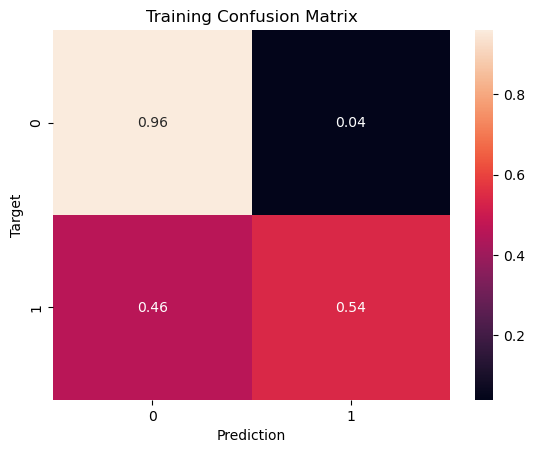

In [36]:
# Виведення точності моделі та побудова матриці невідповідностей для тренувального набору даних
train_preds = predict_and_plot(X_train, train_targets, 'Training')

In [37]:
# Передбачення моделлю на валідаційних даних
val_preds = model.predict(X_val)

In [38]:
# Побудова матриці плутанини (confusion matrix) для валідаційного набору даних

# Обчислення матриці плутанини для валідаційного набору даних
confusion_matrix(val_targets, val_preds)

array([[2847,  140],
       [ 344,  419]])

Accuracy: 87.09%


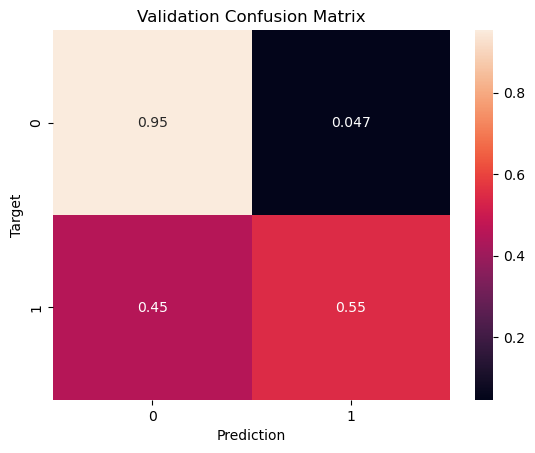

In [39]:
# Виведення точності моделі та побудова матриці невідповідностей для валідаційного набору даних
val_preds = predict_and_plot(X_val, val_targets, 'Validation')

In [40]:
# Обчислення метрики AUROC та побудова ROC Curve для навченої моделі на тренувальних та валідаційних даних

# Задання функції для обчислення метрики AUROC та побудови ROC Curve для заданої моделі
def compute_auroc_and_build_roc(inputs, targets, name = ''):
  # Передбачення ймовірностей
  y_pred_proba = model.predict_proba(inputs)[:, 1]

  # Обяислення ROC curve
  fpr, tpr, thresholds = roc_curve(targets, y_pred_proba, pos_label = 1.0)

  # Обчислення AUROC
  roc_auc = auc(fpr, tpr)
  print(f'AUROC for {name}: {roc_auc:.2f}')

  # Plot the ROC curve
  plt.figure()
  plt.plot(fpr, tpr, color = 'darkorange', lw = 2, label = f'ROC curve (area = {roc_auc:.2f})')
  plt.plot([0, 1], [0, 1], color = 'navy', lw = 2, linestyle = '--')
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(f'Receiver Operating Characteristic (ROC) Curve for {name}')
  plt.legend(loc = "lower right")
  plt.show()

AUROC for Training: 0.88


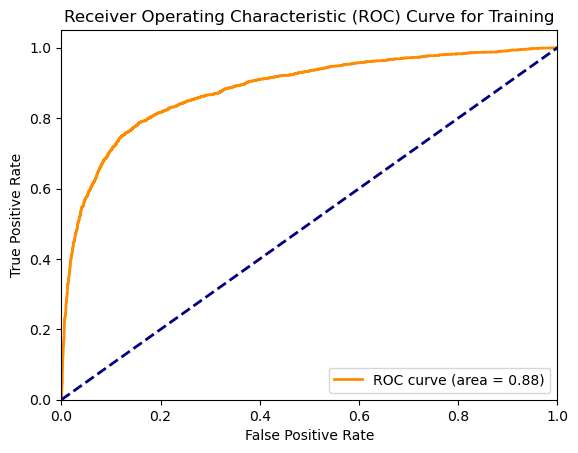

In [41]:
# Обчислення метрики AUROC та побудова ROC Curve для навченої моделі на тренувальних даних
compute_auroc_and_build_roc(X_train, train_targets, 'Training')

AUROC for Validation: 0.88


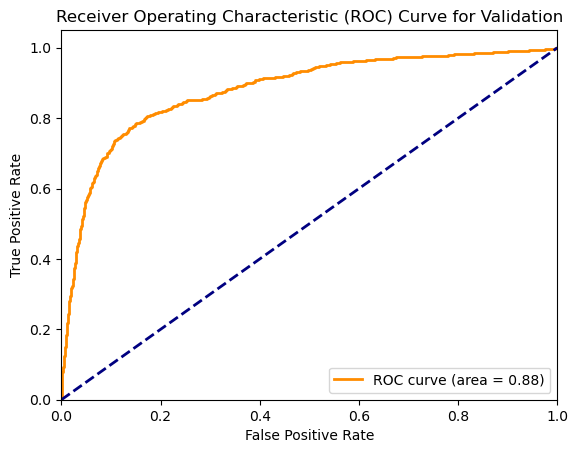

In [42]:
# Обчислення метрики AUROC та побудова ROC Curve для навченої моделі на валідаційних даних
compute_auroc_and_build_roc(X_val, val_targets, 'Validation')

In [43]:
# Обчислення F1 для моделі на тренувальному та валідаційному наборах даних

# Визначення функції для обчислення F1 на заданих даних
def get_f1_score(inputs, targets, name = ''):
  preds = model.predict(inputs)
  f1_score_ = f1_score(targets, preds, pos_label = 1.0)
  print(f"F1 score {name}: {f1_score_:.2f}%")

In [44]:
# Обчислення F1 для моделі на тренувальному наборі даних
get_f1_score(X_train, train_targets, 'Training')

# Обчислення F1 для моделі на валідаційному наборі даних
get_f1_score(X_val, val_targets, 'Validation')

F1 score Training: 0.64%
F1 score Validation: 0.63%


8. Створіть передбачення моделі, яка передбачає завжди мажоритарний клас (той, якого більше в тренувальних даних). Порахуйте Accuracy на тренувальних та валідаційних даних для цієї моделі і тої, що ми натренували в п.6. Зробіть заключення про якість нашої моделі: якість хороша, погана, задовільна?

In [45]:
# Створення моделі, яка передбачає завжди мажоритарний клас (той, якого більше в тренувальних даних)
def all_zeros(inputs):
    return np.full(len(inputs), 0.0)

# Обчислення та виведення точності моделі all_zeros() на тренувальних даних
print(f"Accuracy all_zeros() Training: {accuracy_score(train_targets, all_zeros(X_train)):.2f}")

# Обчислення та виведення точності навченої моделі логістичної регресії на тренувальних даних
print(f"Accuracy Logistic Regression Training: {accuracy_score(train_targets, train_preds):.2f}")

Accuracy all_zeros() Training: 0.80
Accuracy Logistic Regression Training: 0.87


In [46]:
# Обчислення та виведення точності моделі all_zeros() на валідаційних даних
print(f"Accuracy all_zeros() Validation: {accuracy_score(val_targets, all_zeros(X_val)):.2f}")

# Обчислення та виведення точності навченої моделі логістичної регресії на валідаційних даних
print(f"Accuracy Logistic Regression Validation: {accuracy_score(val_targets, val_preds):.2f}")

Accuracy all_zeros() Validation: 0.80
Accuracy Logistic Regression Validation: 0.87


In [60]:
# Висновок про якість навченої моделі логістичної регресії
print("""Порівнявши показники точності на тренувальних та валідаційних даних для навченої моделі логістичної регресії 
(0.87 для обох наборів даних) та точності моделі, яка передбачає завжди клас 0.0 (0.80), бачимо, що навчена 
модель впоралася краще за модель з усіма нулями. Однак перевага навченої моделі не є дуже значною (всього +0.07 
до точності), тому її можна назвати задовільною, оскільки, ймовірно, існують шляхи покращення результативності цієї моделі.""")

Порівнявши показники точності на тренувальних та валідаційних даних для навченої моделі логістичної регресії 
(0.87 для обох наборів даних) та точності моделі, яка передбачає завжди клас 0.0 (0.80), бачимо, що навчена 
модель впоралася краще за модель з усіма нулями. Однак перевага навченої моделі не є дуже значною (всього +0.07 
до точності), тому її можна назвати задовільною, оскільки, ймовірно, існують шляхи покращення результативності цієї моделі.


9. Збережіть модель і інші обʼєкти, які ви хотіли б зберегти, з використанням бібліотеки joblib в файл `log_reg.joblib`. Потім завантажте модель з файлу в змінну `model_2` (цим ми тренуємось завантажувати модель з файлу на майбутнє).

In [48]:
# Збереження моделі з використанням бібліотеки joblib в файл log_reg.joblib

# Створення словника з необхідними об'єктами
сustomer_сhurn = {
    'model': model,
    'scaler': scaler,
    'encoder': enc,
    'input_cols': input_cols,
    'target_col': target_col,
    'numeric_cols': numeric_cols,
    'categorical_cols': categorical_cols,
    'encoded_cols': encoded_cols
}

In [49]:
# Збереження моделі в файл log_reg.joblib
joblib.dump(сustomer_сhurn, 'сustomer_сhurn.joblib')

['сustomer_сhurn.joblib']

In [50]:
# Завантаження моделі з файлу в змінну model_2
model_2 = joblib.load('сustomer_сhurn.joblib')

In [51]:
# Перевірка, чи завантажена модель спрацює так само на валідаційних даних
val_preds2 = model_2['model'].predict(X_val)
accuracy_score(val_targets, val_preds2)

0.8709333333333333

10. Ознайомтесь з роботою наведеної функції `predict_raw_df`. Ця функція робить підготовку даних (масштабування числових колонок і кодування категоріальних) і виводить ймовірності належності до класу 1 для кожного рядка в наданому наборі.

Доповніть або внесіть зміни у функцію з врахуванням вашого препроцесингу даних.

In [52]:
bank_df[numeric_cols]

,id,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15779985.0,678.0,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,1,15650086.0,687.0,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,2,15733602.0,682.0,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,3,15645794.0,753.0,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,4,15633840.0,544.0,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0
...,...,...,...,...,...,...,...,...,...,...,...
14995,14995,15807989.0,585.0,33.0,3.0,0.00,1.0,1.0,0.0,54191.38,0.0
14996,14996,15731781.0,678.0,34.0,6.0,0.00,2.0,1.0,1.0,53437.10,0.0
14997,14997,15667093.0,678.0,54.0,4.0,0.00,1.0,1.0,0.0,147720.29,1.0
14998,14998,15732644.0,705.0,40.0,7.0,0.00,2.0,1.0,0.0,149550.95,0.0


In [53]:
import warnings
warnings.filterwarnings("ignore")

def predict_raw_df(scaler, enc, numeric_cols, categorical_cols, input_df: pd.DataFrame):
    # Копіювання набору даних, щоб не змінювати оригінальний датафрейм
    df = input_df.copy()
    
    # Кодування колонки Gender з бінарними значеннями
    gender_codes = {'Female': 0, 'Male': 1}
    if 'Gender' in df.columns:
        df['Gender_Code'] = df['Gender'].map(gender_codes)
    
    # Трансформування мультикатегоріальної колонки Geography за допомогою навченого OneHotEncoder
    encoded_cols = list(enc.categories_[0])
    df_encoded = pd.DataFrame(enc.transform(df[['Geography']]), columns = encoded_cols, index = df.index)
    df = pd.concat([df, df_encoded], axis = 1)

    # Пошук бінарних колонок у вхідному наборі даних і вилучення колонок 'id', 'Exited', 'CustomerId'
    ignore_cols = ['id', 'Exited', 'CustomerId']
    binary_cols = [
       col for col in numeric_cols 
       if col in df.columns and col not in ignore_cols and set(df[col].dropna().unique()).issubset({0, 1})
    ]
    
    # Вилучення бінарних та службових колонок зі списку для масштабування
    cols_to_scale = [
        col for col in numeric_cols 
        if col not in binary_cols and col not in ignore_cols and col in df.columns
    ]
    
    # Масштабування незалежних числових змінних за допомогою MinMaxScaler
    df[cols_to_scale] = scaler.transform(df[cols_to_scale])
    
    # Визначення фінального набору ознак для моделі в точному порядку, як вони входили в модель
    X_input = df[model_features]
    
    # Обчислення ймовірностей моделлю логістичної регресії
    prob = model.predict_proba(X_input)[:, 1]
    
    return prob

11. Зчитайте дані з `test.csv` в змінну `test_raw_df`. Зробіть передбачення для кожного рядка даних з функцією з попереднього завдання і запишіть результат в нову колонку `Exited` в датафреймі `test_raw_df`.

In [54]:
# Зчитування даних з test.csv в змінну test_raw_df
test_raw_df = pd.read_csv('test.csv')
test_raw_df

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86
1,15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28
2,15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45
3,15003,15785078.0,Martin,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87
4,15004,15662955.0,Kenechukwu,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,24995,15642997.0,Chukwumaobim,639.0,Spain,Male,38.0,10.0,0.00,2.0,1.0,1.0,49637.65
9996,24996,15739271.0,Clements,678.0,Spain,Male,39.0,9.0,0.00,2.0,1.0,1.0,142513.50
9997,24997,15756743.0,Chidiebere,774.0,France,Male,30.0,9.0,0.00,2.0,1.0,0.0,4861.72
9998,24998,15680167.0,Yermakova,595.0,France,Male,38.0,6.0,144875.79,1.0,1.0,0.0,126469.09


In [55]:
# Здійснення передбачення для кожного рядка даних з функцією з попереднього завдання
predicts = predict_raw_df(scaler, enc, numeric_cols, categorical_cols, test_raw_df)
predicts

array([0.07500288, 0.03478113, 0.15069589, ..., 0.0184997 , 0.15227019,
       0.09183248], shape=(10000,))

In [56]:
# Запис результату в нову колонку Exited в датафреймі test_raw_df
test_raw_df['Exited'] = predicts
test_raw_df

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86,0.075003
1,15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28,0.034781
2,15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45,0.150696
3,15003,15785078.0,Martin,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87,0.196290
4,15004,15662955.0,Kenechukwu,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97,0.055185
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,24995,15642997.0,Chukwumaobim,639.0,Spain,Male,38.0,10.0,0.00,2.0,1.0,1.0,49637.65,0.022096
9996,24996,15739271.0,Clements,678.0,Spain,Male,39.0,9.0,0.00,2.0,1.0,1.0,142513.50,0.025971
9997,24997,15756743.0,Chidiebere,774.0,France,Male,30.0,9.0,0.00,2.0,1.0,0.0,4861.72,0.018500
9998,24998,15680167.0,Yermakova,595.0,France,Male,38.0,6.0,144875.79,1.0,1.0,0.0,126469.09,0.152270


12. Зчитайте файл 'sample_submission.csv' і заповніть колонку `Exited` передбаченими вашою моделлю значеннями для кожного відповідного `id` клієнта.
Виведіть перші 5 рядків фінального датасету, збережіть результат в файл `submission_log_reg.csv` (УВАГА! не запишіть випадково ще індекси рядків!) і здайте цей файл на Kaggle зі свого профіля, натиснувши `Submit Prediction`.

In [57]:
# Зчитування даних з sample_submission.csv в змінну sample_submission_df
sample_submission_df = pd.read_csv('sample_submission.csv')
sample_submission_df

,id,Exited
0,15000,0.5
1,15001,0.5
2,15002,0.5
3,15003,0.5
4,15004,0.5
...,...,...
9995,24995,0.5
9996,24996,0.5
9997,24997,0.5
9998,24998,0.5


In [58]:
# Заповнення колонки Exited передбаченими моделлю значеннями для кожного відповідного id клієнта
sample_submission_df['Exited'] = predicts

# Виведeння перших 5 рядків
sample_submission_df.head()

,id,Exited
0,15000,0.075003
1,15001,0.034781
2,15002,0.150696
3,15003,0.196290
4,15004,0.055185


In [59]:
# Збереження результату в файл submission_log_reg.csv
sample_submission_df.to_csv('submission_log_reg.csv', index = False)